# How to Count

## Index

### Multiplication Rule

#### Technical: 

> "Consider a compound experiment consisting of two sub-experiments, Experiment A and Experiment B. Suppose that Experiment A has a possible outcomes, and for each of those outcomes Experiment B has b possible outcomes. Then the compound experiment has ab possible outcomes." (Blitzstein)


*Properties* : 

* Order invariance: The total count does not depend on which choice is made first (2 × 3 = 3 × 2)
* Equal branching required: Every first choice must offer the exact same number of second choices. If restrictions cause varying counts (e.g., 3 vs. 2 options), the multiplication rule fails and you must add cases instead.



#### Analogy

Imagine a tree where each branch splits into the same number of new branches. If you start with 3 branches, and each one splits into 4, you are essentially asking: **how many different paths can I take?**

Each of the 3 first branches has 4 possible continuations, giving:

$$
3 \times 4 = 12
$$

So there are **12 possible paths (outcomes)**.

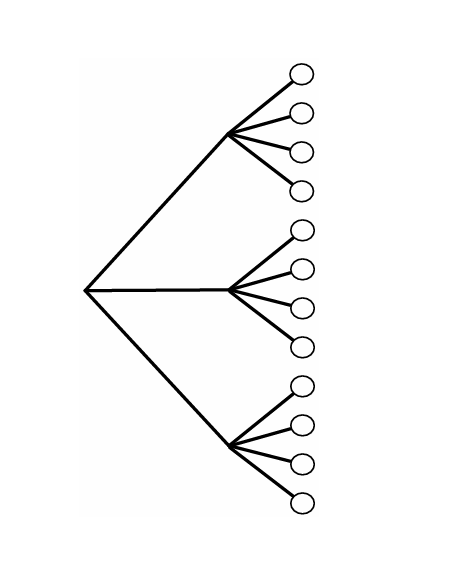

Figure 1.2 - Blitzstein 

#### Example

Example 1.4.5 (Ice cream cones). Suppose you are buying an ice cream cone.
You can choose whether to have a cake cone or a waffle cone, and whether to
have chocolate, vanilla, or strawberry as your flavor. This decision process can be
visualized with a tree diagram, as in Figure 1.4.
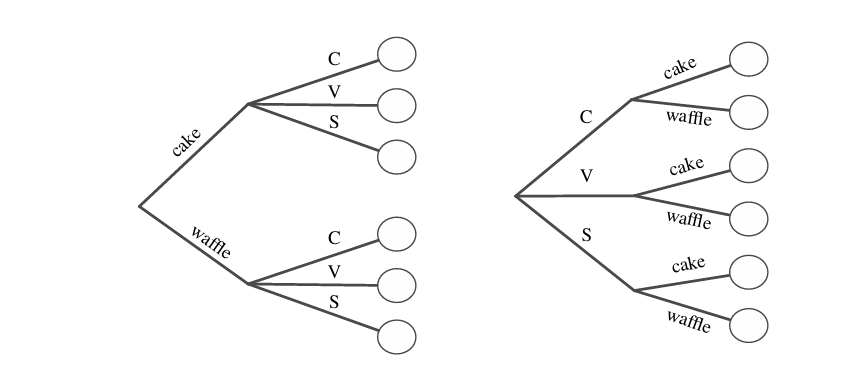

 figure1.4 Blizstein


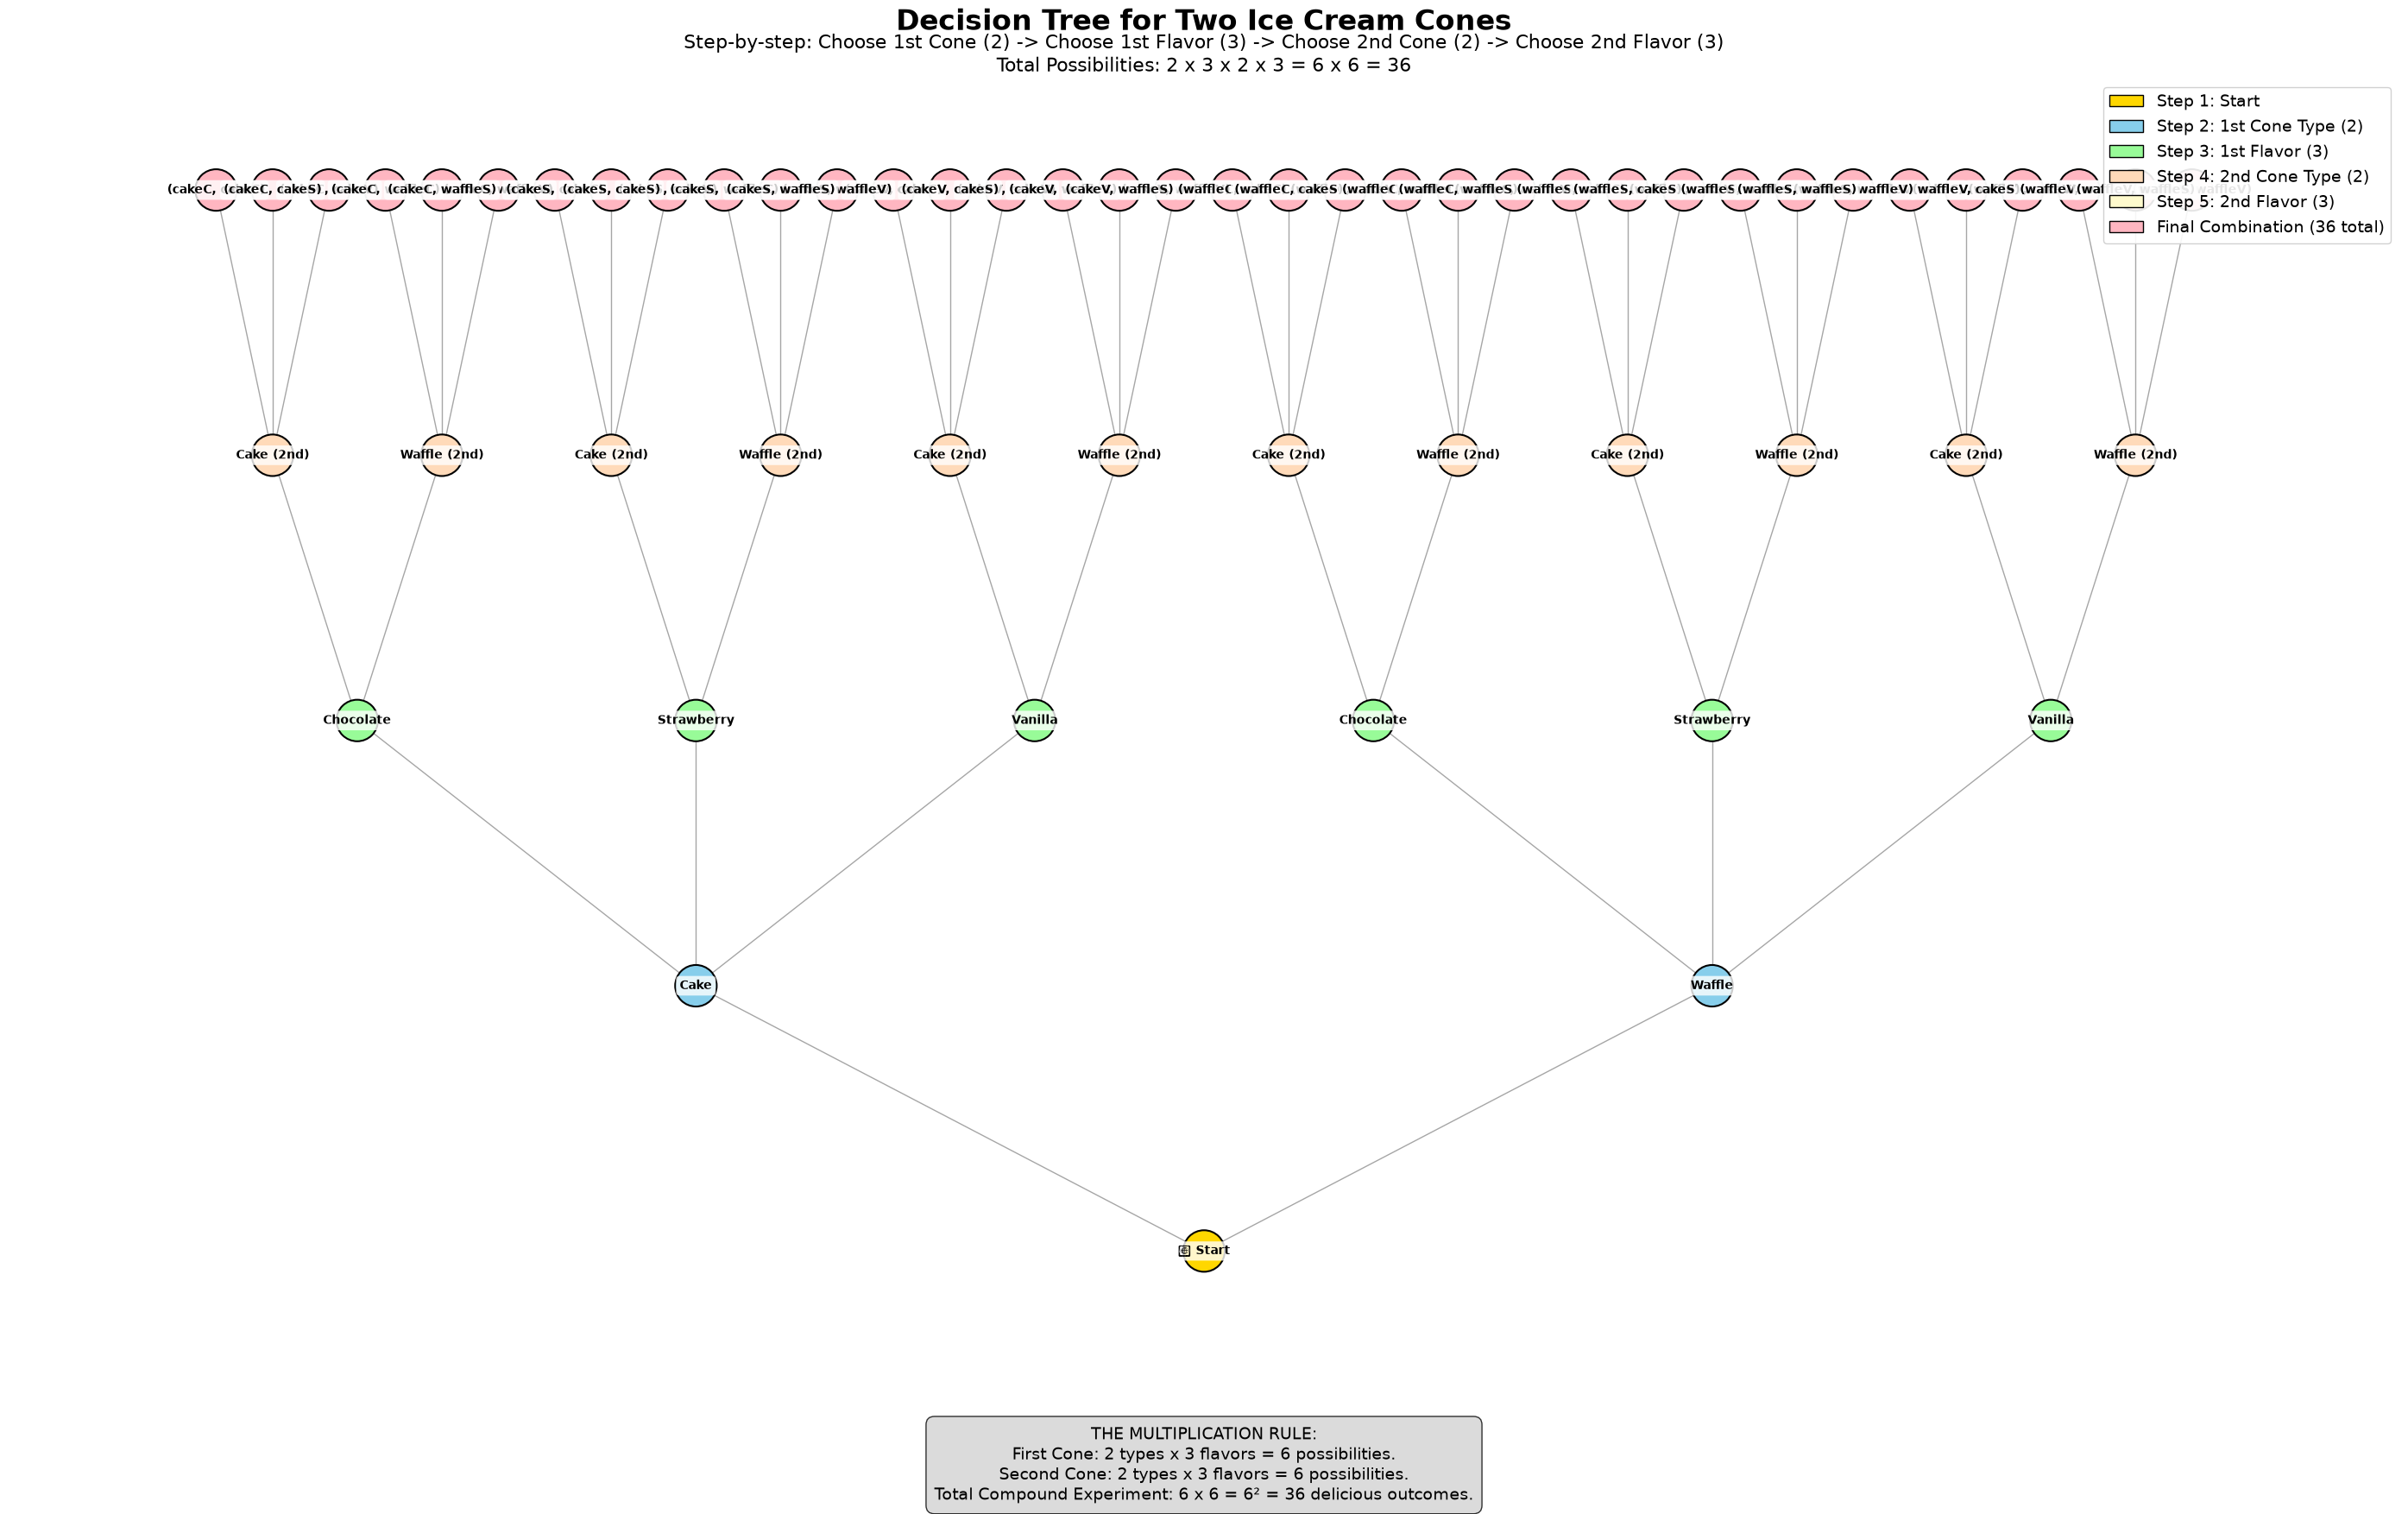

In [8]:
import matplotlib.pyplot as plt
import networkx as nx
from collections import deque
from matplotlib.patches import Patch

def build_tree():
    G = nx.DiGraph()
    cone_types = ["Cake", "Waffle"]
    flavors = ["Chocolate", "Vanilla", "Strawberry"]

    # Step 1: The Start
    root = "Start"
    G.add_node(root, label="🍦 Start", kind="root")

    # Step 2: First Cone Choice (2 options)
    for ct in cone_types:
        node1 = f"{ct}"
        G.add_node(node1, label=ct, kind="cone1")
        G.add_edge(root, node1)

        # Step 3: First Flavor Choice (3 options) -> 2 x 3 = 6 possibilities
        for fl in flavors:
            node2 = f"{ct}-{fl}"
            G.add_node(node2, label=fl, kind="flavor1")
            G.add_edge(node1, node2)

            # Step 4: Second Cone Choice (2 options) -> independent of 1st cone
            for ct2 in cone_types:
                node3 = f"{ct}-{fl}-{ct2}"
                # Label clearly shows this is the 2nd cone choice
                G.add_node(node3, label=f"{ct2} (2nd)", kind="cone2")
                G.add_edge(node2, node3)

                # Step 5: Second Flavor Choice (3 options) -> 6 x 6 = 36 total possibilities
                for fl2 in flavors:
                    node4 = f"{ct}-{fl}-{ct2}-{fl2}"
                    # Leaf label matches user's requested format: (cakeC, waffleV)
                    leaf_label = f"({ct.lower()}{fl[:1]}, {ct2.lower()}{fl2[:1]})"
                    G.add_node(node4, label=leaf_label, kind="leaf")
                    G.add_edge(node3, node4)
    return G

def assign_positions(G, root, h_stretch=1.0):
    """Bottom-up layout with horizontal stretching."""
    q = deque([(root, 0)])
    depths = {}
    level_nodes = {}
    while q:
        node, depth = q.popleft()
        depths[node] = depth
        level_nodes.setdefault(depth, []).append(node)
        for child in G.successors(node):
            q.append((child, depth + 1))

    max_depth = max(depths.values())
    leaves = [n for n in G.nodes if G.out_degree(n) == 0]
    leaves_sorted = sorted(leaves)
    n_leaves = len(leaves_sorted)
    pos = {}
    # Place leaves with uniform spacing, then stretch horizontally
    spacing = h_stretch / (n_leaves - 1) if n_leaves > 1 else 0
    for idx, leaf in enumerate(leaves_sorted):
        pos[leaf] = (idx * spacing, max_depth)

    # Internal nodes: average of children
    for depth in range(max_depth - 1, -1, -1):
        for node in level_nodes.get(depth, []):
            children = list(G.successors(node))
            if children:
                x_avg = sum(pos[child][0] for child in children) / len(children)
                pos[node] = (x_avg, depth)
    return pos

# ----------------------------------------------------------------------
G = build_tree()
pos = assign_positions(G, "Start", h_stretch=2.5)   # Wider tree for clarity

labels = nx.get_node_attributes(G, 'label')

# Enhanced Color mapping for didactic step-by-step learning
kind_colors = {
    "root": "#FFD700",    # Gold (Start)
    "cone1": "#87CEEB",   # Skyblue (1st Cone)
    "flavor1": "#98FB98", # Pale Green (1st Flavor)
    "cone2": "#FFDAB9",   # Peach Puff (2nd Cone)
    "flavor2": "#FFFACD", # Lemon Chiffon (2nd Flavor)
    "leaf": "#FFB6C1"     # Light Pink (Final Combination)
}
node_colors = [kind_colors[G.nodes[n]['kind']] for n in G.nodes]

# Create figure with higher DPI
plt.figure(figsize=(28, 18), dpi=100)

# Draw nodes with larger size
nx.draw_networkx_nodes(G, pos, node_size=1200, node_color=node_colors, edgecolors='black', linewidths=1.5)

# Draw edges
nx.draw_networkx_edges(G, pos, arrows=False, edge_color='gray', alpha=0.7)

# Draw labels with a white background box (bbox) for readability
nx.draw_networkx_labels(
    G, pos, labels,
    font_size=10,          
    font_weight='bold',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.8)
)

# Didactic Title and Subtitle explaining the math rule
plt.suptitle("Decision Tree for Two Ice Cream Cones", fontsize=24, fontweight='bold')
plt.title("Step-by-step: Choose 1st Cone (2) -> Choose 1st Flavor (3) -> Choose 2nd Cone (2) -> Choose 2nd Flavor (3)\nTotal Possibilities: 2 x 3 x 2 x 3 = 6 x 6 = 36", fontsize=16)

# Didactic Legend
legend_elements = [
    Patch(facecolor=kind_colors["root"], edgecolor='black', label='Step 1: Start'),
    Patch(facecolor=kind_colors["cone1"], edgecolor='black', label='Step 2: 1st Cone Type (2)'),
    Patch(facecolor=kind_colors["flavor1"], edgecolor='black', label='Step 3: 1st Flavor (3)'),
    Patch(facecolor=kind_colors["cone2"], edgecolor='black', label='Step 4: 2nd Cone Type (2)'),
    Patch(facecolor=kind_colors["flavor2"], edgecolor='black', label='Step 5: 2nd Flavor (3)'),
    Patch(facecolor=kind_colors["leaf"], edgecolor='black', label='Final Combination (36 total)')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=14, framealpha=0.9)

# Explicit Multiplication Rule explanation
plt.figtext(0.5, 0.02, 
            "THE MULTIPLICATION RULE:\n"
            "First Cone: 2 types x 3 flavors = 6 possibilities.\n"
            "Second Cone: 2 types x 3 flavors = 6 possibilities.\n"
            "Total Compound Experiment: 6 x 6 = 6² = 36 delicious outcomes.",
            ha="center", fontsize=14, bbox=dict(facecolor='lightgrey', alpha=0.8, boxstyle='round,pad=0.5'))

plt.axis('off')
plt.tight_layout(rect=[0, 0.1, 1, 1]) # Adjust layout to accommodate bottom text
plt.show()